In [1]:
# installing dependicies
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.4 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import zipfile

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
zip_path = "YOLO_Ready_Dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

In [4]:
import os

print(os.listdir("/content"))

['.config', 'labels', 'images', 'data.yaml', 'YOLO_Ready_Dataset.zip', 'sample_data']


In [5]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

In [6]:
!cat /content/data.yaml

path: /content/YOLO_Ready_Dataset

train: images/train
val: images/val
test: images/test

names:
  0: Bio-degradable
  1: Non-Biodegradable
  2: E-Waste


In [7]:
data = """path: /content

train: images/train
val: images/val
test: images/test

names:
  0: Bio-degradable
  1: Non-Biodegradable
  2: E-Waste
"""

with open("/content/data.yaml", "w") as f:
    f.write(data)

print("data.yaml updated successfully")

data.yaml updated successfully


In [8]:
import os

print("Train:", os.path.exists("/content/images/train"))
print("Validation:", os.path.exists("/content/images/val"))
print("Test:", os.path.exists("/content/images/test"))

Train: True
Validation: True
Test: True


In [9]:
results = model.train(
    data="/content/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    cos_lr=True,
    cache=True,
    amp=True,
    workers=2,
    pretrained=True,
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=

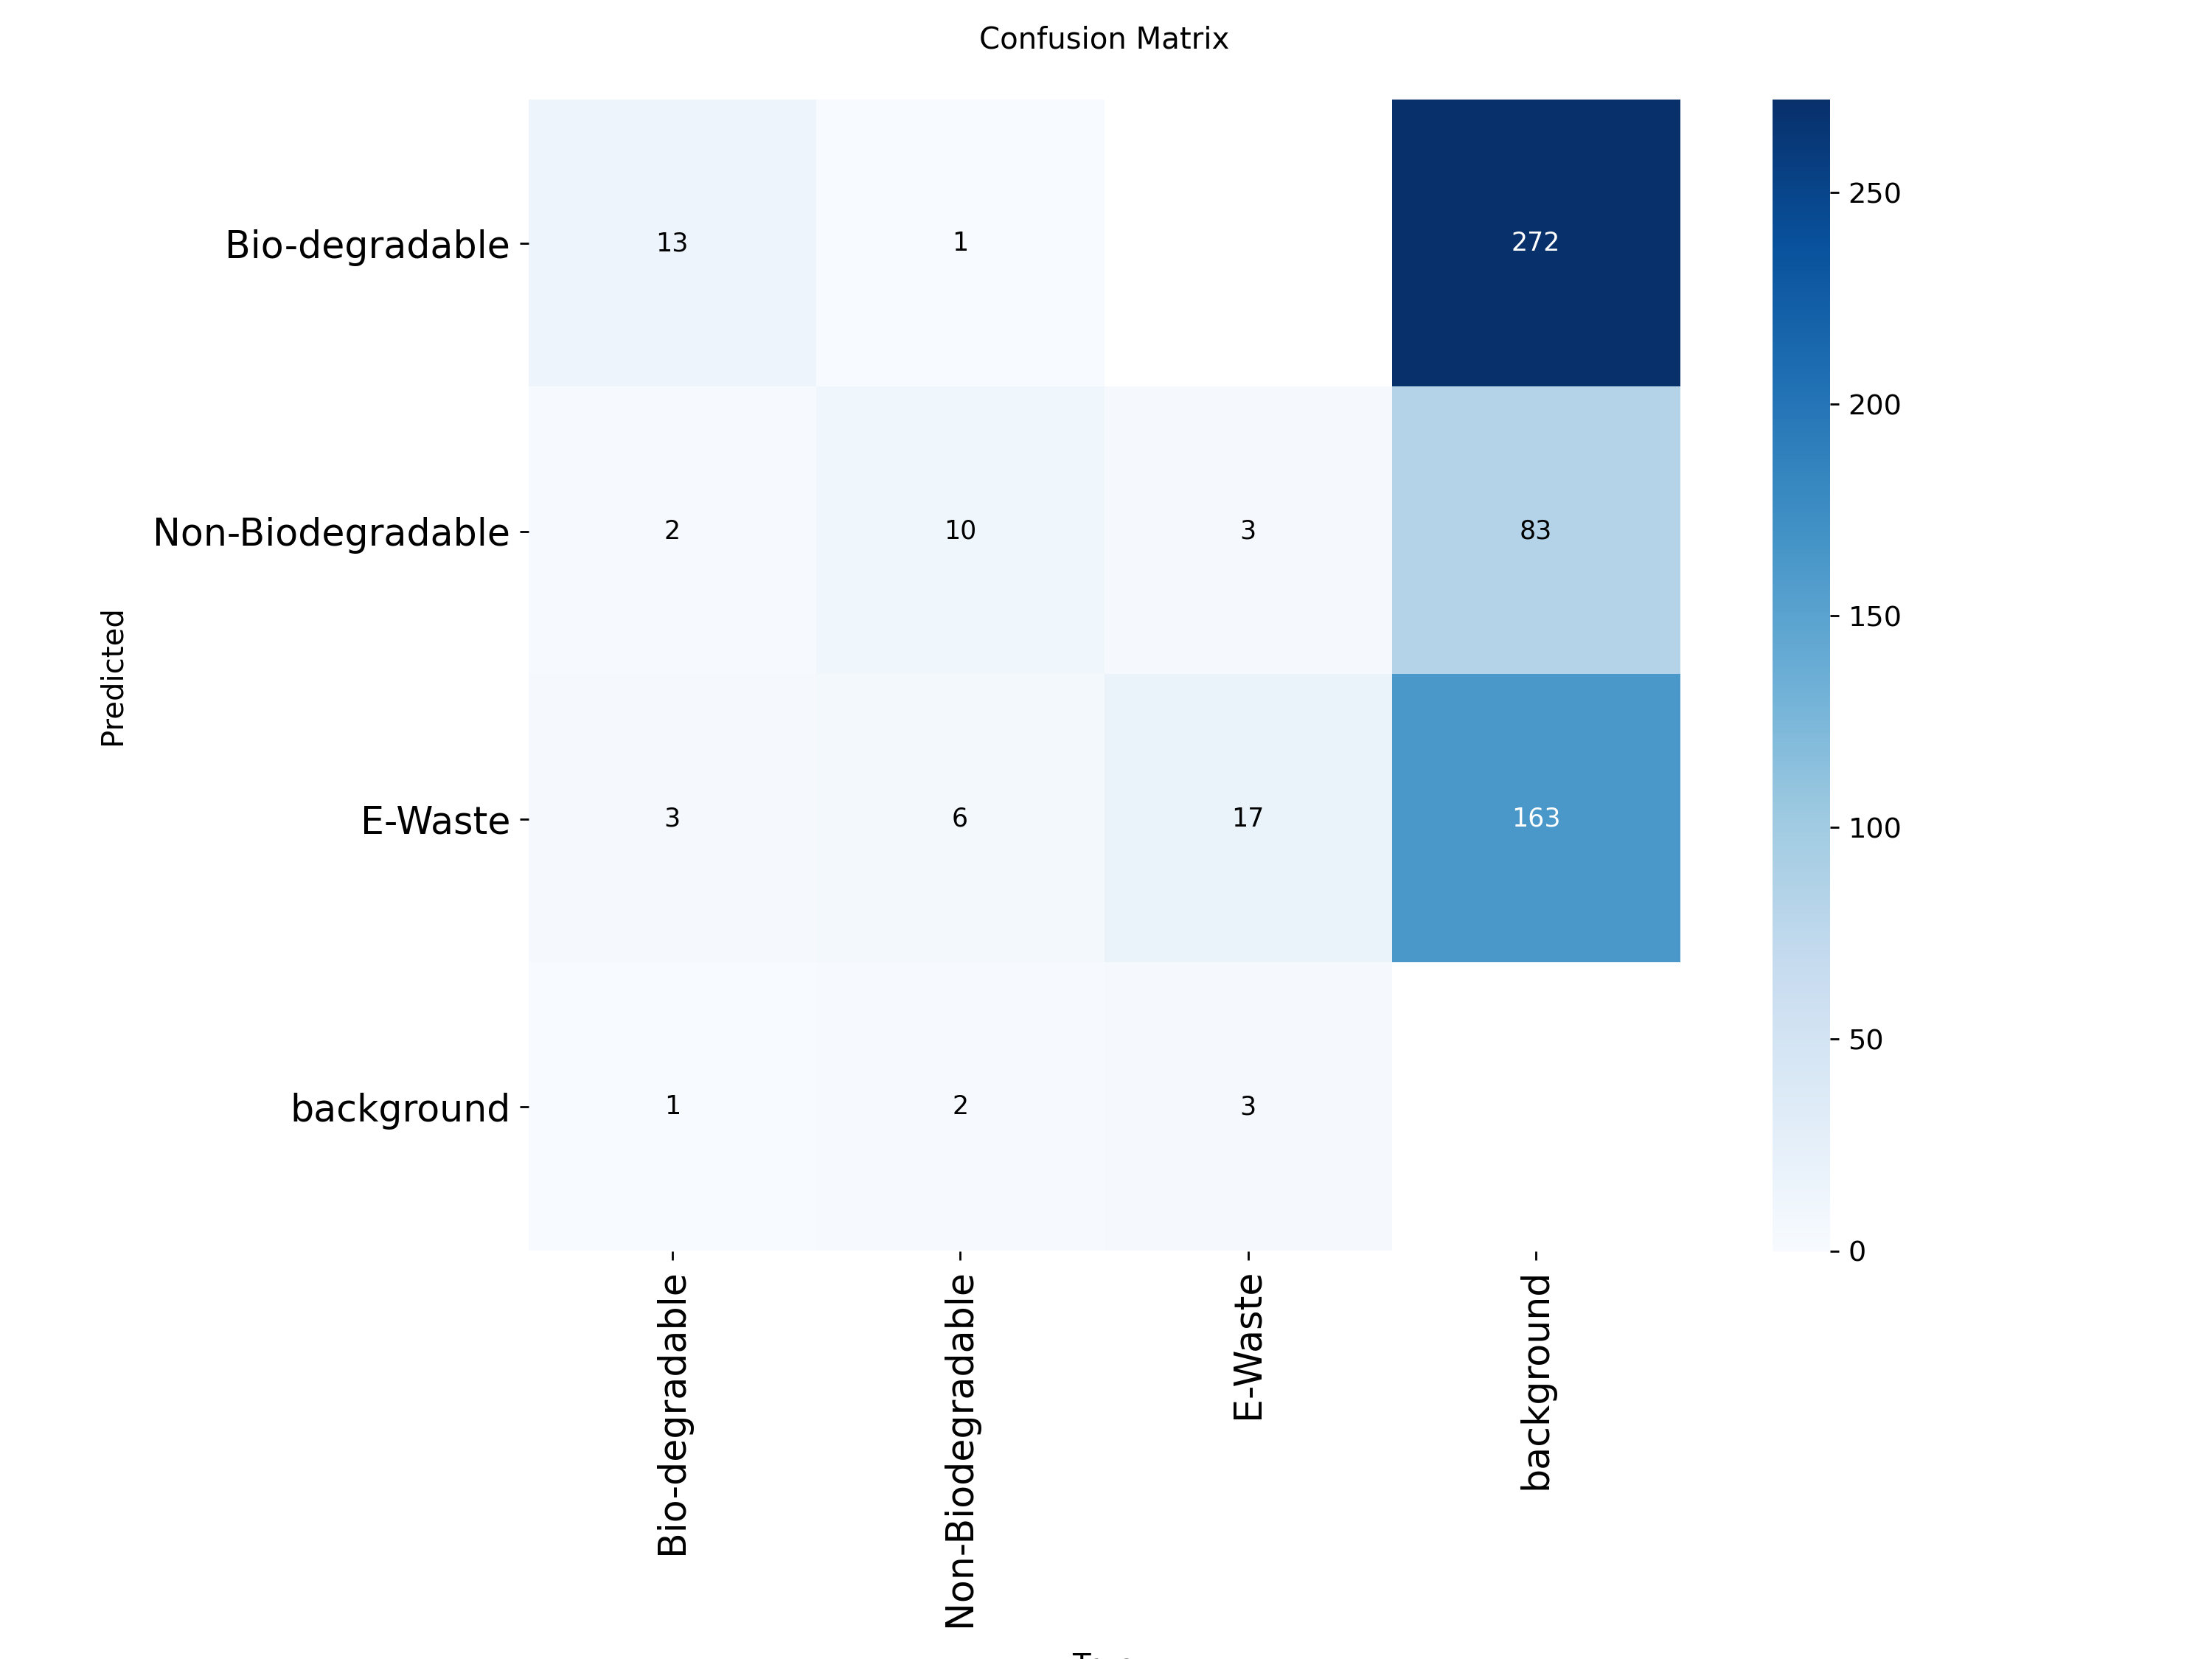

In [10]:
from IPython.display import Image
Image('/content/runs/detect/train/confusion_matrix.png')

In [11]:
from google.colab import files
files.download("/content/runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>